In [1]:
import os
import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt, welch
from scipy.ndimage import uniform_filter1d
import matplotlib.pyplot as plt
import matplotlib as mpl
from collections import Counter
from scipy.stats import linregress, spearmanr
import re
from scipy.stats import shapiro
import scipy.stats as stats
from numpy.polynomial.polynomial import Polynomial

In [2]:
input_folder = "2026 Comparison"

In [3]:
# --- Filter functions ---
nperseg = 1024 
noverlap = nperseg // 2

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a


def butter_bandstop(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='bandstop')
    return b, a


def apply_filters(signal, fs):
    # Ensure numeric array (coerce bad strings to NaN, then interpolate/zero-fill)
    signal = pd.to_numeric(np.asarray(signal).ravel(), errors='coerce').astype(np.float64)
    if not np.isfinite(signal).all():
        signal = pd.Series(signal).interpolate(limit_direction='both').fillna(0.0).to_numpy()


    # Bandpass 1-120 Hz
    b_bp, a_bp = butter_bandpass(1.0, 120.0, fs, 4)
    filtered = filtfilt(b_bp, a_bp, signal)
    # Notch 40-55 Hz
    b_notch, a_notch = butter_bandstop(40.0, 55.0, fs, 1)
    filtered = filtfilt(b_notch, a_notch, filtered)
    # Smoothing (moving average, 5 ms window)
    window_size = max(1, int(fs * (5 / 1000.0)))
    filtered = uniform_filter1d(filtered, size=window_size)
    return filtered


In [4]:
files = [f for f in os.listdir(input_folder) if f.lower().endswith(".csv")] 

def extract_db_group(trial_label):
    match = re.search(r'(?:^|[_\s-])(60|80)\s*dB\b', str(trial_label), flags=re.IGNORECASE)
    if match:
        return f"{int(match.group(1))}dB"
    return None

def append_db_suffix(trial_label, db_group):
    if not db_group:
        return str(trial_label)
    label = str(trial_label).strip()
    if re.search(r'_(?:60|80)dB$', label, flags=re.IGNORECASE):
        return re.sub(r'_(?:60|80)dB$', f'_{db_group}', label, flags=re.IGNORECASE)
    return f"{label}_{db_group}"

# Dictionaries for different trial types
ppi_values = {}  # For capitalized OFFSET trials (dual recordings)
max_values = {}  # For non-offset/control trials
offset_ppi_trials = {}  # For offset_PPI_X and TIN_X trials (separate recordings)
asr_control_trials = {}  # For ASR control trials split by dB group
repetition_tracker = {}

for filename in files:
    filepath = os.path.join(input_folder, filename)
    
    # Load CSV and skip nonsensical rows
    df = pd.read_csv(filepath, low_memory=False, skiprows=[0, 2])

    # Extract animal number and date from filename
    animal_number = filename[:-4].split('_')[0]
    date = filename[:-4].split('_')[1]
    animal_date_key = f"{animal_number}_{date}"

    # Convert value column to numeric
    df.iloc[:, 19] = pd.to_numeric(df.iloc[:, 19], errors='coerce')
    signal = df.iloc[:, 19].values
    
    # Apply filters
    filtered_signal = apply_filters(signal, 500.0)

    # Take absolute value after filtering 
    filtered_signal = np.abs(filtered_signal)
    df.iloc[:, 19] = filtered_signal
    
    # Get Trial column (column 17, 1-indexed = index 16)
    df['trial'] = df.iloc[:, 16].astype(str).str.strip()
    
    # Filter for rows containing 'control', 'offset', or 'tin' (case-insensitive)
    df['is_target'] = df['trial'].str.lower().str.contains('control|offset|tin', na=False)
    df = df[df['is_target']].copy()
    
    if len(df) == 0:
        continue
    
    # Identify segments (consecutive rows with same trial name)
    df['trial_shift'] = df['trial'].shift(1)
    df['new_segment'] = df['trial'] != df['trial_shift']
    df['segment_id'] = df['new_segment'].cumsum()
    
    # Process each segment
    for segment_id, segment_df in df.groupby('segment_id'):
        trial_name = segment_df.iloc[0]['trial']
        trial_name_lower = str(trial_name).lower()
        db_group = extract_db_group(trial_name)
        
        # Create unique key for this animal+trial combination
        normalized_trial_name = append_db_suffix(trial_name, db_group)
        animal_trial_key = f"{animal_number}_{normalized_trial_name}"
        
        # Increment repetition counter
        if animal_trial_key not in repetition_tracker:
            repetition_tracker[animal_trial_key] = 0
        repetition_tracker[animal_trial_key] += 1
        
        unique_key = f"{animal_number}_{normalized_trial_name}_Rep{repetition_tracker[animal_trial_key]}"
        
        # Get max value for this segment
        max_val = segment_df.iloc[:, 19].max()
        
        is_offset_ppi = re.search(r'offset[_\s-]*ppi(?:[_\s-]*(?:\d+|old))?(?=$|[_\s-])', trial_name_lower, flags=re.IGNORECASE) is not None
        is_tin = re.search(r'(?:^|[_\s-])tin(?:[_\s-]*(?:\d+|old))?(?=$|[_\s-])', trial_name_lower, flags=re.IGNORECASE) is not None

        # Check if this is a capitalized OFFSET trial (dual recording with split)
        if 'offset' in trial_name_lower and not is_offset_ppi and not is_tin:
            # Split at MS = 15000 (column 18, 0-indexed)
            segment_df['MS'] = pd.to_numeric(segment_df.iloc[:, 18], errors='coerce')
            split_idx = segment_df[segment_df['MS'] >= 15000].index
            
            if len(split_idx) > 0:
                # First segment: prepulse+startle (PPS)
                first_half = segment_df.loc[:split_idx[0]-1]
                # Second segment: startle alone (S)
                second_half = segment_df.loc[split_idx[0]:]
                
                if len(first_half) > 0 and len(second_half) > 0:
                    PPS = first_half.iloc[:, 19].max()
                    S = second_half.iloc[:, 19].max()
                    
                    # Calculate %PPI = 100 * ((S - PPS) / S)
                    if S != 0:
                        ppi_percent = 100 * ((S - PPS) / S)
                        ppi_values[unique_key] = ppi_percent
                    else:
                        ppi_values[unique_key] = np.nan
                else:
                    ppi_values[unique_key] = max_val
            else:
                ppi_values[unique_key] = max_val
        
        # Check if this is offset_PPI_X trial (separate recording)
        elif is_offset_ppi:
            trial_type_match = re.search(r'offset[_\s-]*ppi[_\s-]*(\d+|old)(?=$|[_\s-])', trial_name, flags=re.IGNORECASE)
            if trial_type_match:
                suffix = trial_type_match.group(1)
                if str(suffix).lower() == 'old':
                    trial_type = 'offset_PPI_old'
                else:
                    trial_type = f"offset_PPI_{int(suffix)}"
            else:
                trial_type = 'offset_PPI'

            trial_type = append_db_suffix(trial_type, db_group)
            key = f"{animal_date_key}_{trial_type}"
            if key not in offset_ppi_trials:
                offset_ppi_trials[key] = []
            offset_ppi_trials[key].append(max_val)
        
        # Check if this is a TIN trial (TIN_X variants, including TIN_old)
        elif is_tin:
            tin_match = re.search(r'tin[_\s-]*(\d+|old)(?=$|[_\s-])', trial_name, flags=re.IGNORECASE)
            if tin_match:
                tin_suffix = tin_match.group(1)
                if str(tin_suffix).lower() == 'old':
                    trial_type = 'TIN_old'
                else:
                    trial_type = f"TIN_{int(tin_suffix)}"
            else:
                trial_type = 'TIN'

            trial_type = append_db_suffix(trial_type, db_group)
            key = f"{animal_date_key}_{trial_type}"
            if key not in offset_ppi_trials:
                offset_ppi_trials[key] = []
            offset_ppi_trials[key].append(max_val)
        
        # Check if this is an ASR control trial
        elif 'control' in trial_name_lower and 'asr' in trial_name_lower:
            control_group = db_group if db_group else 'unknown'
            key = f"{animal_date_key}_{control_group}"
            if key not in asr_control_trials:
                asr_control_trials[key] = []
            asr_control_trials[key].append(max_val)
        
        else:
            # Other trials - just save the maximum
            max_values[unique_key] = max_val

# Calculate %PPI for offset_PPI and TIN trials by comparing to matching ASR controls
matched_count = 0
unmatched_count = 0
unmatched_trials = []

print("\n" + "="*70)
print("MATCHING offset_PPI/TIN TRIALS WITH ASR CONTROLS (same animal, date, and dB group)")
print("="*70)

for offset_key, offset_values in offset_ppi_trials.items():
    # Extract animal_date and trial type
    parts = offset_key.split('_')
    animal = parts[0]
    date = parts[1]
    trial_type = '_'.join(parts[2:])  # e.g., offset_PPI_10_60dB or TIN_10_80dB
    animal_date_key = f"{animal}_{date}"
    db_group = extract_db_group(trial_type)
    control_group_key = f"{animal_date_key}_{db_group}" if db_group else f"{animal_date_key}_unknown"
    
    # Get corresponding ASR control values for the same dB group
    if control_group_key in asr_control_trials:
        avg_offset = np.mean(offset_values)
        avg_control = np.mean(asr_control_trials[control_group_key])
        
        # Calculate %PPI = 100 * ((S_control - PPS_offset) / S_control)
        if avg_control != 0:
            ppi_percent = 100 * ((avg_control - avg_offset) / avg_control)
            ppi_key = f"{animal}_{date}_{trial_type}"
            ppi_values[ppi_key] = ppi_percent
            matched_count += 1
            print(f"✓ {animal} {date} {trial_type}: matched with {len(asr_control_trials[control_group_key])} ASR control(s)")
        else:
            print(f"⚠ {animal} {date} {trial_type}: ASR control = 0, skipping")
            unmatched_count += 1
            unmatched_trials.append(offset_key)
    else:
        print(f"✗ {animal} {date} {trial_type}: NO MATCHING ASR CONTROL FOUND FOR {db_group if db_group else 'unknown'}")
        unmatched_count += 1
        unmatched_trials.append(offset_key)

print("\n" + "="*70)
print(f"MATCHING SUMMARY:")
print(f"  Successfully matched: {matched_count}")
print(f"  Unmatched/skipped:    {unmatched_count}")
print("="*70)

if unmatched_trials:
    print("\nWARNING: The following offset_PPI/TIN trials had no matching ASR controls:")
    for trial in unmatched_trials:
        print(f"  - {trial}")

print(f"\nProcessed {len(ppi_values)} %PPI values ({sum(1 for k in ppi_values.keys() if ('offset_PPI' in k or 'TIN_' in k))} from offset_PPI/TIN trials).")
print(f"Processed {len(max_values)} other trial segments.")


MATCHING offset_PPI/TIN TRIALS WITH ASR CONTROLS (same animal, date, and dB group)
✓ Animal57 March10 offset_PPI_10_60dB: matched with 5 ASR control(s)
✓ Animal57 March10 offset_PPI_16_80dB: matched with 5 ASR control(s)
✓ Animal57 March10 TIN_4_60dB: matched with 5 ASR control(s)
✓ Animal57 March10 TIN_16_60dB: matched with 5 ASR control(s)
✓ Animal57 March10 offset_PPI_4_60dB: matched with 5 ASR control(s)
✓ Animal57 March10 offset_PPI_10_80dB: matched with 5 ASR control(s)
✓ Animal57 March10 offset_PPI_4_80dB: matched with 5 ASR control(s)
✓ Animal57 March10 TIN_old_80dB: matched with 5 ASR control(s)
✓ Animal57 March10 TIN_10_60dB: matched with 5 ASR control(s)
✓ Animal57 March10 TIN_old_60dB: matched with 5 ASR control(s)
✓ Animal57 March10 TIN_16_80dB: matched with 5 ASR control(s)
✓ Animal57 March10 TIN_10_80dB: matched with 5 ASR control(s)
✓ Animal57 March10 offset_PPI_16_60dB: matched with 5 ASR control(s)
✓ Animal57 March10 TIN_4_80dB: matched with 5 ASR control(s)
✓ Animal

In [5]:
# Convert to DataFrames
ppi_df = pd.DataFrame(list(ppi_values.items()), columns=['Key', '%PPI'])
max_df = pd.DataFrame(list(max_values.items()), columns=['Key', 'Max_ValueG'])

print("\nSample %PPI entries:")
print(ppi_df.head())
print("\nSample Max Value entries:")
print(max_df.head())

# Calculate mean %PPI per trial
def normalize_db_suffix(text):
    return re.sub(r'_(?:60|80)db$', lambda m: m.group(0).replace('db', 'dB'), str(text), flags=re.IGNORECASE)

def split_db_suffix(trial_label):
    trial_label = str(trial_label)
    m = re.search(r'_(60|80)dB$', trial_label, flags=re.IGNORECASE)
    if not m:
        return trial_label, np.nan
    db_group = f"{int(m.group(1))}dB"
    base = re.sub(r'_(?:60|80)dB$', '', trial_label, flags=re.IGNORECASE)
    return base, db_group

def extract_trial_name(key):
    key = str(key)
    db_match = re.search(r'_(60|80)dB$', key, flags=re.IGNORECASE)
    db_suffix = f"_{int(db_match.group(1))}dB" if db_match else ""
    key_no_db = re.sub(r'_(?:60|80)dB$', '', key, flags=re.IGNORECASE)

    # Handle matched offset_PPI trials (format: Animal_Date_offset_PPI_X[_60dB/_80dB])
    if re.search(r'offset[_\s-]*PPI', key_no_db, flags=re.IGNORECASE):
        match = re.search(r'(offset[_\s-]*PPI[_\s-]*(?:\d+|old))(?:$|_)', key_no_db, flags=re.IGNORECASE)
        if match:
            normalized = re.sub(r'offset[_\s-]*PPI', 'offset_PPI', match.group(1), flags=re.IGNORECASE)
            normalized = re.sub(r'offset_PPI[_\s-]*(\d+|old)$', r'offset_PPI_\1', normalized, flags=re.IGNORECASE)
            return normalize_db_suffix(normalized + db_suffix)
        if db_suffix:
            return f"offset_PPI{db_suffix}"
        return 'offset_PPI'

    # Handle matched TIN trials (format: Animal_Date_TIN_X[_60dB/_80dB] or TIN_old[_60dB/_80dB])
    if re.search(r'(?:^|_)TIN(?:_|$)', key_no_db, flags=re.IGNORECASE):
        match = re.search(r'(TIN_(?:\d+|old))(?:$|_)', key_no_db, flags=re.IGNORECASE)
        if match:
            return normalize_db_suffix(match.group(1) + db_suffix)
        if db_suffix:
            return f"TIN{db_suffix}"
        return 'TIN'

    # Format: Animal_Trial_RepN - extract Trial part
    match = re.search(r'Animal\d+_(.+)_Rep\d+', key, flags=re.IGNORECASE)
    if match:
        return normalize_db_suffix(match.group(1))
    return normalize_db_suffix(key)

ppi_df['Trial'] = ppi_df['Key'].apply(extract_trial_name)
ppi_df[['Trial_Base', 'dB_Group']] = ppi_df['Trial'].apply(lambda t: pd.Series(split_db_suffix(t)))
ppi_df['dB_Group'] = ppi_df['dB_Group'].astype('object')

# Numeric offset length is extracted only from trial base, never from dB suffix
ppi_df['Offset_Length'] = ppi_df['Trial_Base'].str.extract(
    r'(?:^|_)(?:OFFSET|offset[_\s-]*PPI|TIN)[_\s-]*(\d+)(?:$|_)', flags=re.IGNORECASE
)[0].astype(float)

# Remove negative %PPI values
pre_neg_count = len(ppi_df)
ppi_df = ppi_df[ppi_df['%PPI'] >= 0].reset_index(drop=True)
removed_neg = pre_neg_count - len(ppi_df)
print(f"\nRemoved {removed_neg} negative %PPI values.")

# Remove outliers within each trial (IQR-based)
def filter_outliers_iqr(group, value_col='%PPI', k=1.5, min_n=4):
    if len(group) < min_n:
        return group
    q1 = group[value_col].quantile(0.25)
    q3 = group[value_col].quantile(0.75)
    iqr = q3 - q1
    if iqr == 0 or not np.isfinite(iqr):
        return group
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return group[group[value_col].between(lower, upper)]

pre_outlier_count = len(ppi_df)
ppi_df = ppi_df.groupby('Trial', group_keys=False).apply(filter_outliers_iqr).reset_index(drop=True)
removed = pre_outlier_count - len(ppi_df)
print(f"\nRemoved {removed} %PPI outliers across trials (IQR-based).")

# Group by trial and calculate mean
mean_ppi_per_trial = ppi_df.groupby('Trial')['%PPI'].mean().sort_values(ascending=False)

print("\n\nMean %PPI per Trial:")
print("=" * 50)
for trial, mean_ppi in mean_ppi_per_trial.items():
    print(f"{trial:30s}: {mean_ppi:7.2f}%")


Sample %PPI entries:
                            Key       %PPI
0   Animal57_OFFSET_4_60dB_Rep1  67.965350
1  Animal57_OFFSET_10_60dB_Rep1  17.921685
2  Animal57_OFFSET_10_80dB_Rep1  40.680437
3  Animal57_OFFSET_10_80dB_Rep2  37.574175
4  Animal57_OFFSET_16_60dB_Rep1   4.378505

Sample Max Value entries:
Empty DataFrame
Columns: [Key, Max_ValueG]
Index: []

Removed 16 negative %PPI values.

Removed 5 %PPI outliers across trials (IQR-based).


Mean %PPI per Trial:
offset_PPI_10_80dB            :   55.65%
TIN_4_60dB                    :   52.79%
offset_PPI_16_80dB            :   52.36%
OFFSET_16_80dB                :   52.13%
TIN_10_60dB                   :   48.83%
OFFSET_10_60dB                :   41.71%
OFFSET_10_80dB                :   41.11%
TIN_16_60dB                   :   40.19%
OFFSET_4_60dB                 :   38.65%
TIN_4_80dB                    :   37.33%
OFFSET_16_60dB                :   37.15%
OFFSET_4_80dB                 :   31.43%
TIN_16_80dB                   :   31.30

C:\Users\1kolb\AppData\Local\Temp\ipykernel_7756\3830527477.py:84: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ppi_df = ppi_df.groupby('Trial', group_keys=False).apply(filter_outliers_iqr).reset_index(drop=True)




%PPI vs. Offset Length (split by trial family and dB):

OFFSET:
--------------------------------------------------------------------------------
  60dB:
  Offset Length (ms)   Mean %PPI       Std Dev         N         
  4                             38.65          26.86        16
  10                            41.71          21.34        15
  16                            37.15          21.65        17
  Spearman (60dB): rho=-0.5000, p=0.6667
  80dB:
  Offset Length (ms)   Mean %PPI       Std Dev         N         
  4                             31.43          12.63        16
  10                            41.11          24.32        19
  16                            52.13          24.05        20
  Spearman (80dB): rho=1.0000, p=0.0000

offset_PPI:
--------------------------------------------------------------------------------
  60dB:
  Offset Length (ms)   Mean %PPI       Std Dev         N         
  4                             24.53          10.50         3
  10           

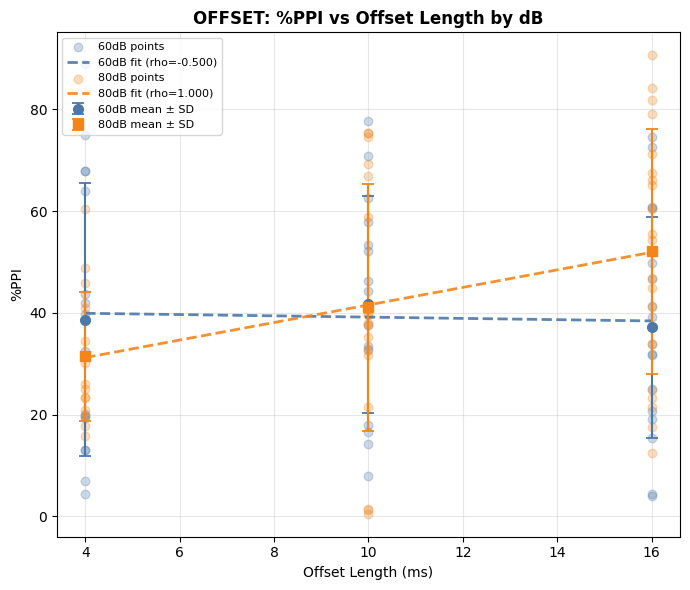

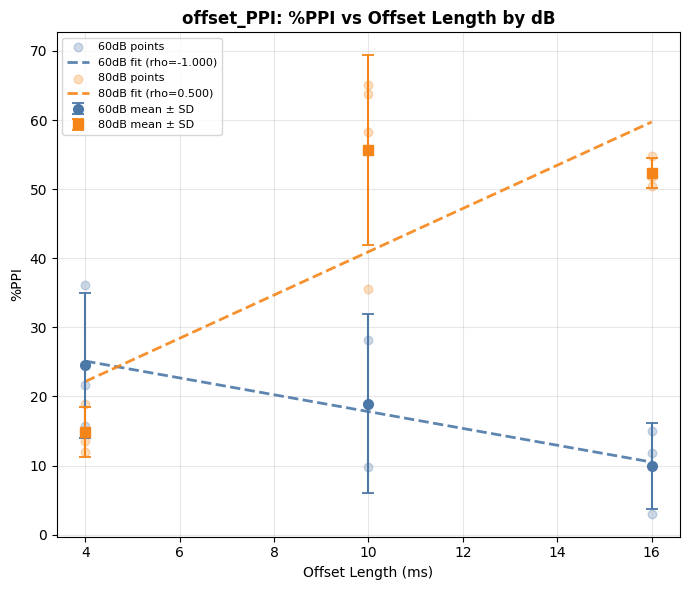

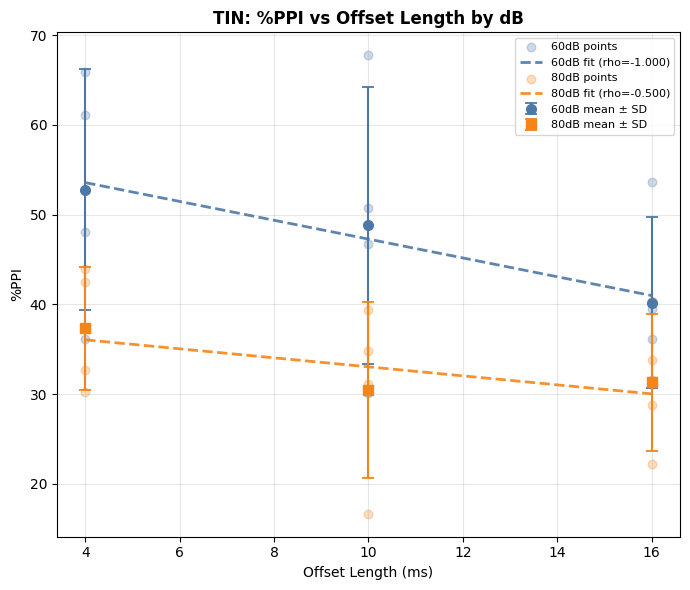



%PPI Comparison: 60dB vs 80dB by Trial Family

OFFSET:
               mean        std  count
dB_Group                             
60dB      39.072510  22.997939     48
80dB      42.302784  22.721066     55
Mann-Whitney U p-value: 0.4691

offset_PPI:
               mean        std  count
dB_Group                             
60dB      17.660865  10.615135      8
80dB      42.407751  20.780227     10
Mann-Whitney U p-value: 0.0205

TIN:
               mean        std  count
dB_Group                             
60dB      41.041128  17.306219     15
80dB      31.388871   7.971366     15
Mann-Whitney U p-value: 0.0890


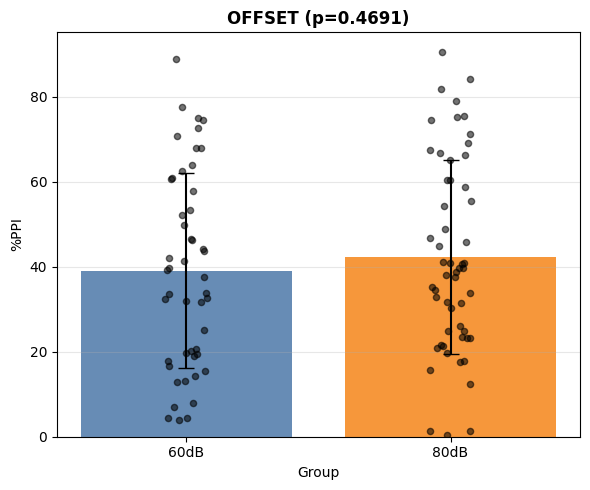

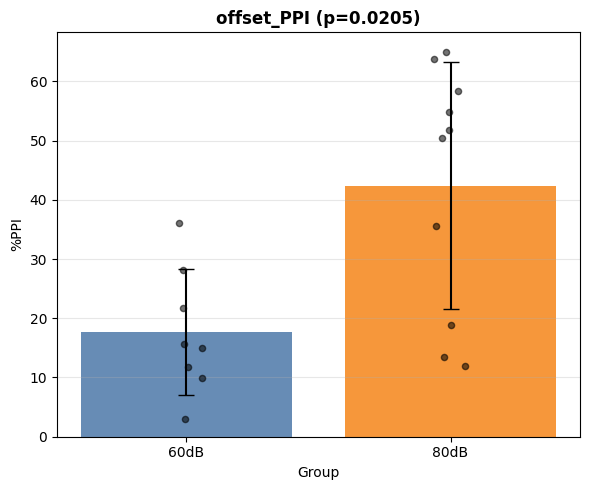

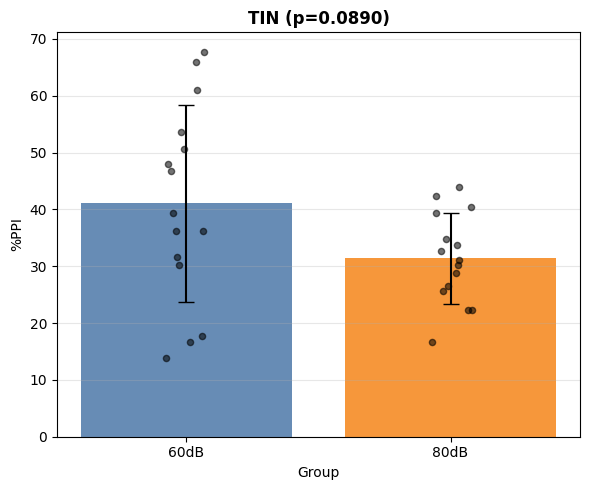

In [6]:
# Check if %PPI increases with offset length, split by trial family
# Families: OFFSET, offset_PPI, TIN

# Keep trials of interest
offset_trials = ppi_df[ppi_df['Trial'].str.contains(r'OFFSET|offset[_\s-]*PPI|TIN', case=False, na=False, regex=True)].copy()

# Label trial family
offset_trials['Trial_Type'] = np.select(
    [
        offset_trials['Trial'].str.contains(r'offset[_\s-]*PPI', case=False, na=False, regex=True),
        offset_trials['Trial'].str.contains('TIN', case=False, na=False),
        offset_trials['Trial'].str.contains('OFFSET', case=False, na=False)
    ],
    ['offset_PPI', 'TIN', 'OFFSET'],
    default='Other'
 )

# Use pre-parsed numeric offset length so 60dB/80dB suffix is never treated as offset length
offset_trials['Offset_Length'] = pd.to_numeric(offset_trials['Offset_Length'], errors='coerce')

# Remove rows without numeric offset (e.g., TIN_old, offset_PPI_60dB without explicit offset number)
offset_trials = offset_trials.dropna(subset=['Offset_Length'])

# Keep only rows with explicit dB group for split analysis
offset_trials = offset_trials[offset_trials['dB_Group'].isin(['60dB', '80dB'])].copy()

if len(offset_trials) > 0:
    print("\n\n%PPI vs. Offset Length (split by trial family and dB):")
    print("=" * 90)

    trial_order = ['OFFSET', 'offset_PPI', 'TIN']
    db_order = ['60dB', '80dB']
    db_colors = {'60dB': '#4C78A8', '80dB': '#F58518'}
    db_markers = {'60dB': 'o', '80dB': 's'}

    summaries = {}
    test_results = {}

    for trial_type in trial_order:
        trial_data = offset_trials[offset_trials['Trial_Type'] == trial_type].copy()
        if len(trial_data) == 0:
            continue

        print(f"\n{trial_type}:")
        print("-" * 80)

        for db_group in db_order:
            trial_db_data = trial_data[trial_data['dB_Group'] == db_group].copy()
            if len(trial_db_data) == 0:
                continue

            summary = trial_db_data.groupby('Offset_Length')['%PPI'].agg(['mean', 'std', 'count']).sort_index().reset_index()
            summaries[(trial_type, db_group)] = summary

            print(f"  {db_group}:")
            print(f"  {'Offset Length (ms)':<20} {'Mean %PPI':<15} {'Std Dev':<15} {'N':<10}")
            for row in summary.itertuples(index=False):
                std_val = 0.0 if pd.isna(row.std) else row.std
                print(f"  {int(row.Offset_Length):<20} {row.mean:>14.2f} {std_val:>14.2f} {int(row.count):>9}")

            if len(summary) >= 2 and summary['Offset_Length'].nunique() >= 2:
                corr, p_val = spearmanr(summary['Offset_Length'], summary['mean'])
                test_results[(trial_type, db_group)] = (corr, p_val)
                print(f"  Spearman ({db_group}): rho={corr:.4f}, p={p_val:.4f}")
            else:
                test_results[(trial_type, db_group)] = (np.nan, np.nan)
                print(f"  Spearman ({db_group}): not run (need at least 2 offset lengths).")

    available_families = [
        t for t in trial_order
        if any((t, db) in summaries for db in db_order)
    ]

    if available_families:
        for trial_type in available_families:
            fig, ax = plt.subplots(figsize=(7, 6))
            for db_group in db_order:
                key = (trial_type, db_group)
                if key not in summaries:
                    continue

                trial_db_data = offset_trials[
                    (offset_trials['Trial_Type'] == trial_type) & (offset_trials['dB_Group'] == db_group)
                ]
                summary = summaries[key]
                color = db_colors[db_group]
                marker = db_markers[db_group]

                ax.scatter(
                    trial_db_data['Offset_Length'],
                    trial_db_data['%PPI'],
                    alpha=0.28, color=color, s=38, label=f'{db_group} points', zorder=1
                )

                ax.errorbar(
                    summary['Offset_Length'],
                    summary['mean'],
                    yerr=summary['std'].fillna(0),
                    fmt=marker, color=color, markersize=7, capsize=4, capthick=1.3,
                    label=f'{db_group} mean ± SD', zorder=3
                )

                if len(summary) >= 2 and summary['Offset_Length'].nunique() >= 2:
                    p = Polynomial.fit(summary['Offset_Length'], summary['mean'], 1)
                    x_line = np.linspace(summary['Offset_Length'].min(), summary['Offset_Length'].max(), 100)
                    y_line = p(x_line)
                    rho, _ = test_results[key]
                    ax.plot(
                        x_line, y_line, '--', color=color, linewidth=2, alpha=0.9,
                        label=f'{db_group} fit (rho={rho:.3f})', zorder=2
                    )

            ax.set_title(f'{trial_type}: %PPI vs Offset Length by dB', fontweight='bold')
            ax.set_xlabel('Offset Length (ms)')
            ax.set_ylabel('%PPI')
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8)
            plt.tight_layout()
            plt.show()
    else:
        print("\nNo eligible family/dB combinations found for relationship plotting.")

else:
    print("\nNo OFFSET/offset_PPI/TIN trials with numeric lengths and dB groups found in the data.")

# Compare %PPI between 60dB and 80dB groups per trial family
group_ppi = ppi_df.copy()
if 'dB_Group' not in group_ppi.columns:
    group_ppi['dB_Group'] = group_ppi['Trial'].str.extract(r'_(60dB|80dB)$', flags=re.IGNORECASE)[0]
group_ppi['dB_Group'] = group_ppi['dB_Group'].astype(str).str.replace('DB', 'dB', regex=False)

if 'Trial_Base' not in group_ppi.columns:
    group_ppi['Trial_Base'] = group_ppi['Trial'].str.replace(r'_(?:60|80)dB$', '', regex=True, flags=re.IGNORECASE)

group_ppi['Trial_Family'] = np.select(
    [
        group_ppi['Trial_Base'].str.contains(r'offset[_\s-]*PPI', case=False, na=False, regex=True),
        group_ppi['Trial_Base'].str.contains(r'(?:^|_)TIN(?:_|$)', case=False, na=False, regex=True),
        group_ppi['Trial_Base'].str.contains(r'OFFSET', case=False, na=False, regex=True)
    ],
    ['offset_PPI', 'TIN', 'OFFSET'],
    default='Other'
)

group_ppi = group_ppi.dropna(subset=['dB_Group', '%PPI']).copy()
group_ppi = group_ppi[group_ppi['dB_Group'].isin(['60dB', '80dB'])]
group_ppi = group_ppi[group_ppi['Trial_Family'].isin(['OFFSET', 'offset_PPI', 'TIN'])]

families = ['OFFSET', 'offset_PPI', 'TIN']
available_families = []

print("\n\n%PPI Comparison: 60dB vs 80dB by Trial Family")
print("=" * 70)

for fam in families:
    fam_df = group_ppi[group_ppi['Trial_Family'] == fam].copy()
    if fam_df.empty:
        print(f"\n{fam}: no data")
        continue

    g60 = fam_df.loc[fam_df['dB_Group'] == '60dB', '%PPI'].dropna()
    g80 = fam_df.loc[fam_df['dB_Group'] == '80dB', '%PPI'].dropna()

    if len(g60) == 0 or len(g80) == 0:
        print(f"\n{fam}: not enough data for both groups (60dB n={len(g60)}, 80dB n={len(g80)})")
        continue

    available_families.append(fam)
    fam_summary = (
        fam_df.groupby('dB_Group')['%PPI']
        .agg(['mean', 'std', 'count'])
        .reindex(['60dB', '80dB'])
    )

    u_stat, p_val = stats.mannwhitneyu(g60, g80, alternative='two-sided')
    print(f"\n{fam}:")
    print(fam_summary)
    print(f"Mann-Whitney U p-value: {p_val:.4f}")

if available_families:
    x_order = ['60dB', '80dB']
    bar_colors = ['#4C78A8', '#F58518']

    for fam in available_families:
        fig, ax = plt.subplots(figsize=(6, 5))
        fam_df = group_ppi[group_ppi['Trial_Family'] == fam].copy()
        fam_summary = (
            fam_df.groupby('dB_Group')['%PPI']
            .agg(['mean', 'std', 'count'])
            .reindex(x_order)
        )

        means = fam_summary['mean'].values
        errs = fam_summary['std'].fillna(0).values
        ax.bar(x_order, means, yerr=errs, capsize=6, color=bar_colors, alpha=0.85)

        for i, grp in enumerate(x_order):
            y = fam_df.loc[fam_df['dB_Group'] == grp, '%PPI'].to_numpy()
            jitter = np.random.uniform(-0.08, 0.08, size=len(y))
            ax.scatter(np.full(len(y), i) + jitter, y, color='black', alpha=0.55, s=20, zorder=3)

        g60 = fam_df.loc[fam_df['dB_Group'] == '60dB', '%PPI'].dropna()
        g80 = fam_df.loc[fam_df['dB_Group'] == '80dB', '%PPI'].dropna()
        _, p_val = stats.mannwhitneyu(g60, g80, alternative='two-sided')

        ax.set_title(f'{fam} (p={p_val:.4f})', fontweight='bold')
        ax.set_xlabel('Group')
        ax.set_ylabel('%PPI')
        ax.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("\nNot enough data to compare 60dB vs 80dB within OFFSET/offset_PPI/TIN families.")